In [1]:
# =============================================================================
#  PER-YEAR SARIMA — v4  (RUN-ONCE pipeline for Kaggle)
# -----------------------------------------------------------------------------
#  WHY THIS VERSION EXISTS
#  -----------------------
#  
#    1. It re-ran the whole grid search every time, even when you only wanted to
#       recolour a plot. Grid search is the slow part (tens of minutes).
#    2. The "best order" table was a matplotlib table whose column headers
#       overlapped and were unreadable.
#    3. Saving fitted SARIMA model objects (pickles) makes huge files; Kaggle
#       output then becomes too large.
#
#  THE FIX: split into two stages.
#    STAGE 1 (SLOW, run ONCE) -> grid search + rolling forecast, then save ONLY
#            small artefacts to disk:  best params, metrics, forecast values,
#            grid-search log.  NO fitted models are ever pickled.
#    STAGE 2 (FAST, run anytime) -> read those CSVs back and rebuild every table
#            and figure.  Tomorrow you tweak a colour/label and re-run: Stage 1
#            is skipped automatically because the cache already exists.
#
#  HOW TO REUSE THE CACHE NEXT DAY ON KAGGLE
#  -----------------------------------------
#  Kaggle wipes /kaggle/working between sessions. To keep the slow Stage-1
#  result across days:
#    (1) Run this notebook once (Stage 1 writes CSVs into /kaggle/working/...).
#    (2) "Save Version" so Kaggle stores /kaggle/working as the notebook Output.
#    (3) Next day, add that Output as an input dataset, and set
#        PRECOMPUTED_DIR below to its path (e.g.
#        "/kaggle/input/<your-notebook-output>/sarima_outputs").
#    Now Stage 1 is skipped and only the fast plotting/table code runs.
# =============================================================================

In [2]:


import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

# ---- global style (clean, thesis-grade) ------------------------------------
plt.rcParams.update({
    "figure.dpi":        110,
    "savefig.dpi":       150,        # file quality; keeps notebook size sane
    "font.size":         11,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.labelsize":    11,
    "axes.edgecolor":    "#888888",
    "axes.grid":         True,
    "grid.color":        "#e6e6e6",
    "grid.linewidth":    0.8,
    "legend.frameon":    True,
    "legend.framealpha": 0.9,
    "legend.fontsize":   9.5,
})
C_ACTUAL  = "#1f3b73"   # deep blue
C_SARIMA  = "#d1495b"   # warm red
C_NAIVE   = "#2a9d8f"   # teal
C_HEADER  = "#1f3b73"
C_ROW_A   = "#f4f7fb"
C_ROW_B   = "#ffffff"
C_BEST    = "#d8f3dc"   # light green highlight

In [3]:
# =============================================================================
# CONFIG
# =============================================================================
paths = [
    "/kaggle/input/datasets/sidratsamia/eia-electricity-data-v2/data/eia_demand_hourly_2019.csv",
    "/kaggle/input/datasets/sidratsamia/eia-electricity-data-v2/data/eia_demand_hourly_2020.csv",
    "/kaggle/input/datasets/sidratsamia/eia-electricity-data-v2/data/eia_demand_hourly_2021.csv",
    "/kaggle/input/datasets/sidratsamia/eia-electricity-data-v2/data/eia_demand_hourly_2022.csv",
    "/kaggle/input/datasets/sidratsamia/eia-electricity-data-v2/data/eia_demand_hourly_2023.csv",
    "/kaggle/input/datasets/sidratsamia/eia-electricity-data-v2/data/eia_demand_hourly_2024.csv",
    "/kaggle/input/datasets/sidratsamia/eia-electricity-data-v2/data/eia_demand_hourly_2025.csv",
    "/kaggle/input/datasets/sidratsamia/eia-electricity-data-v2/data/eia_demand_hourly_2026_partial.csv",
]

WORK_DIR        = "/kaggle/working/sarima_outputs"   # where Stage 1 WRITES
FIG_DIR         = os.path.join(WORK_DIR, "figures")
FC_DIR          = os.path.join(WORK_DIR, "forecasts")
PRECOMPUTED_DIR = None        # set to an attached-dataset path to REUSE a run
FORCE_RECOMPUTE = False       # True -> redo Stage 1 even if cache exists

TRAIN_FRAC  = 0.80
S           = 24              # daily seasonal period
H           = 24             # rolling (walk-forward) horizon = day-ahead
MAXITER     = 50
FAST_SEARCH = False           # short curated candidate list (minutes)

for d in (WORK_DIR, FIG_DIR, FC_DIR):
    os.makedirs(d, exist_ok=True)

if FAST_SEARCH:
    CANDIDATES = [
        ((1, 1, 1), (1, 1, 1, S)),
        ((2, 1, 1), (1, 1, 1, S)),
        ((1, 1, 2), (1, 1, 1, S)),
        ((2, 1, 2), (1, 1, 1, S)),
        ((2, 1, 2), (2, 1, 1, S)),
        ((2, 1, 3), (2, 1, 2, S)),
    ]

else:
    # EDA-informed grid: p,P in {1,2}, q in {2,3}, Q in {1,2}, d=D=1, s=24
    P_, D_, Q_ = [1, 2], [1], [1, 2]
    p_, d_, q_ = [1, 2], [1], [2, 3]
    grid = [((pi, di, qi), (Pi, Di, Qi, S))
            for pi in p_ for di in d_ for qi in q_
            for Pi in P_ for Di in D_ for Qi in Q_]          # 16 models
    anchors = [                                              # parsimonious refs
        ((1, 1, 1), (1, 1, 1, S)),
        ((1, 1, 1), (0, 1, 1, S)),
        ((2, 1, 2), (1, 1, 1, S)),
    ]
    CANDIDATES = anchors + grid                              # 19 per year, 152 total

# Where Stage 2 READS from: a precomputed dataset if given, else our work dir.
CACHE_DIR = PRECOMPUTED_DIR or WORK_DIR
CACHE_FC  = os.path.join(CACHE_DIR, "forecasts")

In [4]:

# =============================================================================
# SHARED HELPERS
# =============================================================================
def load_clean_series(path):
    """One gap-free hourly series per file (drop DST dup hour, regular grid)."""
    df = pd.read_csv(path)
    df.columns = [c.lower() for c in df.columns]
    if "type" in df.columns:
        df = df[df["type"] == "D"]
    df["period"] = pd.to_datetime(df["period"], format="%Y-%m-%dT%H", errors="coerce")
    if df["period"].isna().any():
        df["period"] = pd.to_datetime(df["period"], errors="coerce")
    s = pd.Series(pd.to_numeric(df["value"], errors="coerce").values, index=df["period"])
    s = s[~s.index.isna()]
    s = s[~s.index.duplicated(keep="first")].sort_index()
    full = pd.date_range(s.index.min(), s.index.max(), freq="h")
    s = s.reindex(full).interpolate(method="time").ffill().bfill()
    s.name = "value"; s.index.freq = "h"
    return s

def mape(y, f):
    y, f = np.asarray(y, float), np.asarray(f, float); m = y != 0
    return np.mean(np.abs((y[m] - f[m]) / y[m])) * 100

def smape(y, f):
    y, f = np.asarray(y, float), np.asarray(f, float)
    d = np.abs(y) + np.abs(f); d = np.where(d == 0, 1e-9, d)
    return np.mean(2 * np.abs(f - y) / d) * 100

def evaluate(y, f):
    return {"MAE": mean_absolute_error(y, f),
            "RMSE": np.sqrt(mean_squared_error(y, f)),
            "MAPE": mape(y, f), "sMAPE": smape(y, f),
            "R2": r2_score(y, f)}


# =============================================================================
# STAGE 1 — SLOW. Grid-search (train only) + rolling forecast. Save CSVs only.
# =============================================================================
def grid_search_sarima(train, maxiter=MAXITER):
    rows = []
    for order, seasonal in CANDIDATES:
        try:
            t0 = time.time()
            res = SARIMAX(train, order=order, seasonal_order=seasonal,
                          enforce_stationarity=False, enforce_invertibility=False
                          ).fit(disp=False, method="lbfgs", maxiter=maxiter)
            rows.append({"order": str(order), "seasonal": str(seasonal),
                         "aic": float(res.aic), "bic": float(res.bic),
                         "secs": round(time.time() - t0, 1)})
        except Exception:
            rows.append({"order": str(order), "seasonal": str(seasonal),
                         "aic": np.inf, "bic": np.inf, "secs": np.nan})
    tbl = pd.DataFrame(rows).sort_values("aic").reset_index(drop=True)
    best = CANDIDATES[[str(o) for o, _ in CANDIDATES].index(tbl.loc[0, "order"])]
    return best, tbl

def rolling_forecast(train, test, order, seasonal, horizon=H, maxiter=MAXITER):
    """Fit ONCE, forecast `horizon` h, feed TRUE values back (no refit), roll."""
    res = SARIMAX(train, order=order, seasonal_order=seasonal,
                  enforce_stationarity=False, enforce_invertibility=False
                  ).fit(disp=False, method="lbfgs", maxiter=maxiter)
    aic, preds, hist = float(res.aic), [], res
    for i in range(0, len(test), horizon):
        block = test.iloc[i:i + horizon]
        fc = hist.get_forecast(steps=len(block)).predicted_mean
        fc.index = block.index
        preds.append(fc)
        hist = hist.append(block, refit=False)
    return pd.concat(preds), aic   # NOTE: `hist` (the fitted model) is discarded

def seasonal_naive(train, test, lag):
    return pd.concat([train, test]).shift(lag).reindex(test.index)

def stage1_compute_and_cache():
    metrics_rows, best_rows, search_log = [], [], []
    print("STAGE 1: grid search + rolling forecast (run once)...")
    for p in paths:
        s = load_clean_series(p)
        year = int(s.index[0].year)
        cut = int(len(s) * TRAIN_FRAC)
        train, test = s.iloc[:cut], s.iloc[cut:]

        best, stbl = grid_search_sarima(train)
        stbl.insert(0, "year", year); search_log.append(stbl)

        fc, aic = rolling_forecast(train, test, best[0], best[1])
        sn24, sn168 = seasonal_naive(train, test, 24), seasonal_naive(train, test, 168)

        # --- save forecast VALUES (small CSV; lets us rebuild plots w/o model) --
        pd.DataFrame({"actual": test, "sarima": fc.values,
                      "naive24": sn24.values, "naive168": sn168.values},
                     index=test.index).to_csv(os.path.join(FC_DIR, f"forecast_{year}.csv"))

        for name, f in [("SARIMA", fc), ("Naive-24h", sn24), ("Naive-168h", sn168)]:
            m = evaluate(test, f)
            metrics_rows.append({"Year": year, "Model": name,
                                 "order": str(best[0]), "seasonal": str(best[1]),
                                 "AIC": round(aic, 1),
                                 **{k: round(v, 3) for k, v in m.items()}})
        best_rows.append({"Year": year, "order": str(best[0]), "seasonal": str(best[1]),
                          "AIC": round(aic, 1),
                          **{k: round(v, 3) for k, v in evaluate(test, fc).items()}})
        print(f"  {year}: best={best[0]}{best[1]}  SARIMA MAPE={evaluate(test, fc)['MAPE']:.2f}%")

    pd.DataFrame(metrics_rows).to_csv(os.path.join(WORK_DIR, "metrics_all_models.csv"), index=False)
    pd.DataFrame(best_rows).to_csv(os.path.join(WORK_DIR, "best_params_per_year.csv"), index=False)
    pd.concat(search_log, ignore_index=True).to_csv(os.path.join(WORK_DIR, "grid_search_log.csv"), index=False)
    print(f"STAGE 1 done. Small CSVs saved to {WORK_DIR} (no models pickled).")


# =============================================================================
# STAGE 2 — FAST. Load cache, build polished tables + figures.
# =============================================================================
def cache_exists():
    need = [os.path.join(CACHE_DIR, "metrics_all_models.csv"),
            os.path.join(CACHE_DIR, "best_params_per_year.csv")]
    return all(os.path.exists(f) for f in need)

def load_cache():
    metrics = pd.read_csv(os.path.join(CACHE_DIR, "metrics_all_models.csv"))
    best    = pd.read_csv(os.path.join(CACHE_DIR, "best_params_per_year.csv"))
    fcs = {}
    for y in sorted(best["Year"]):
        fp = os.path.join(CACHE_FC, f"forecast_{y}.csv")
        if os.path.exists(fp):
            fcs[y] = pd.read_csv(fp, index_col=0, parse_dates=True)
    return metrics, best, fcs


# ---------- polished table renderer (fixes the header overlap) ---------------
def render_table_png(df, path, title, col_labels, col_widths,
                     highlight_min=None, highlight_max=None):
    n = len(df)
    fig_h = 0.46 * n + 1.25
    fig, ax = plt.subplots(figsize=(11, fig_h))
    ax.axis("off")
    ax.set_title(title, fontweight="bold", fontsize=13, pad=10, color="#222")

    tbl = ax.table(cellText=df.values, colLabels=col_labels,
                   colWidths=col_widths, loc="center", cellLoc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)

    ncol = len(col_labels)
    for (r, c), cell in tbl.get_celld().items():
        cell.set_edgecolor("#cfd8e3")
        cell.set_linewidth(0.8)
        if r == 0:                                   # header row
            cell.set_facecolor(C_HEADER)
            cell.set_text_props(color="white", fontweight="bold")
            cell.set_height(cell.get_height() * 2.1) # tall header -> 2-line labels fit
        else:
            cell.set_facecolor(C_ROW_A if r % 2 else C_ROW_B)
            cell.set_height(cell.get_height() * 1.25)

    # highlight best cells per requested column (by header name)
    def col_idx(name): return col_labels.index(name)
    if highlight_min:
        for name in highlight_min:
            j = col_idx(name); vals = pd.to_numeric(df.iloc[:, j], errors="coerce")
            r = int(vals.idxmin()) + 1
            tbl[(r, j)].set_facecolor(C_BEST); tbl[(r, j)].set_text_props(fontweight="bold")
    if highlight_max:
        for name in highlight_max:
            j = col_idx(name); vals = pd.to_numeric(df.iloc[:, j], errors="coerce")
            r = int(vals.idxmax()) + 1
            tbl[(r, j)].set_facecolor(C_BEST); tbl[(r, j)].set_text_props(fontweight="bold")

    plt.savefig(path, dpi=150, bbox_inches="tight", facecolor="white")
    plt.show(); plt.close()


def build_tables(metrics, best):
    # --- Table A: best SARIMA per year -------------------------------------
    A = best.copy()
    A["Year"] = A["Year"].astype(int)
    A = A[["Year", "order", "seasonal", "AIC", "MAE", "RMSE", "MAPE", "R2"]].reset_index(drop=True)
    labelsA = ["Year", "Order\n(p, d, q)", "Seasonal\n(P, D, Q, s)",
               "AIC", "MAE\n(MWh)", "RMSE\n(MWh)", "MAPE\n(%)", "R²"]
    render_table_png(
        A, os.path.join(FIG_DIR, "table_best_sarima.png"),
        "Table 1.  Best SARIMA configuration per year (order chosen on TRAIN via AIC)",
        col_labels=labelsA,
        col_widths=[0.08, 0.16, 0.20, 0.14, 0.13, 0.13, 0.09, 0.07],
        highlight_min=["MAPE\n(%)", "RMSE\n(MWh)"], highlight_max=["R²"])

    # --- Table B: model comparison (MAPE %) --------------------------------
    piv = metrics.pivot_table(index="Year", columns="Model", values="MAPE").reset_index()
    piv["Year"] = piv["Year"].astype(int)
    piv = piv[["Year", "SARIMA", "Naive-24h", "Naive-168h"]].reset_index(drop=True)
    piv["Winner"] = piv[["SARIMA", "Naive-24h", "Naive-168h"]].idxmin(axis=1)
    render_table_png(
        piv, os.path.join(FIG_DIR, "table_model_comparison.png"),
        "Table 2.  Test-set MAPE (%) — SARIMA vs seasonal-naive baselines  (lower = better)",
        col_labels=["Year", "SARIMA\n(daily)", "Naive\n24 h", "Naive\n168 h", "Best\nmodel"],
        col_widths=[0.10, 0.18, 0.16, 0.16, 0.18])
    print("Saved Table 1 and Table 2 to", FIG_DIR)
    return A, piv


def plot_year(year, fc_df, best):
    """Full-test panel + last-14-day zoom, fully labelled, weekends shaded."""
    row = best[best["Year"] == year].iloc[0]
    sub = (f"Order {row['order']} × Seasonal {row['seasonal']}   |   "
           f"MAPE {row['MAPE']:.2f}%   RMSE {row['RMSE']:,.0f} MWh   R² {row['R2']:.2f}")
    actual, sarima, sn168 = fc_df["actual"], fc_df["sarima"], fc_df["naive168"]

    fig, ax = plt.subplots(2, 1, figsize=(14, 8.5),
                           gridspec_kw={"height_ratios": [1, 1], "hspace": 0.32})
    fig.suptitle(f"SARIMA day-ahead forecast — {year}", fontsize=15, fontweight="bold", y=0.98)
    fig.text(0.5, 0.935, sub, ha="center", fontsize=10, color="#555")

    # (a) full test horizon
    ax[0].plot(actual.index, actual, color=C_ACTUAL, lw=1.1, label="Actual demand")
    ax[0].plot(sarima.index, sarima, color=C_SARIMA, lw=1.0, alpha=.9, label="SARIMA (rolling 24 h)")
    ax[0].plot(sn168.index, sn168, color=C_NAIVE, lw=0.8, ls="--", alpha=.55, label="Naive-168 h (weekly)")
    ax[0].set_title(f"(a) Full test period  ({len(actual)} hours ≈ {len(actual)//24} days)", loc="left")
    ax[0].set_ylabel("Demand (MWh)")
    ax[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))
    ax[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax[0].legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.0))

    # (b) last 14 days, weekend shading to show the weekly cycle SARIMA(s=24) ignores
    zoom = actual.index[-336:]
    a2, s2 = actual.loc[zoom], sarima.loc[zoom]
    ax[1].plot(zoom, a2, color=C_ACTUAL, lw=1.6, label="Actual")
    ax[1].plot(zoom, s2, color=C_SARIMA, lw=1.6, label="SARIMA")
    for d0 in pd.date_range(zoom.min().normalize(), zoom.max(), freq="D"):
        if d0.dayofweek >= 5:
            ax[1].axvspan(d0, d0 + pd.Timedelta(days=1), color="#ffd166", alpha=0.18, lw=0)
    ax[1].set_title("(b) Last 14 days (zoom).  Shaded = weekends", loc="left")
    ax[1].set_xlabel("Date"); ax[1].set_ylabel("Demand (MWh)")
    ax[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))
    ax[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax[1].legend(loc="upper right")

    plt.savefig(os.path.join(FIG_DIR, f"forecast_{year}.png"), dpi=150,
                bbox_inches="tight", facecolor="white")
    plt.show(); plt.close()


def plot_error_overview(metrics, best):
    fig, ax = plt.subplots(1, 2, figsize=(15, 5.2))

    # left: MAPE lines, SARIMA vs baselines
    for model, style in [("SARIMA", dict(color=C_SARIMA, marker="o", lw=2.2, ms=7, zorder=3)),
                         ("Naive-24h", dict(color=C_NAIVE, marker="s", lw=1.4, ms=5)),
                         ("Naive-168h", dict(color="#e9954b", marker="^", lw=1.4, ms=5))]:
        g = metrics[metrics["Model"] == model].sort_values("Year")
        ax[0].plot(g["Year"], g["MAPE"], label=model, **style)
    ax[0].set_title("(a) Forecast accuracy by year — SARIMA beats both baselines", loc="left")
    ax[0].set_xlabel("Year"); ax[0].set_ylabel("MAPE (%)  (lower = better)")
    ax[0].legend()

    # right: SARIMA MAE & RMSE grouped bars with value labels
    b = best.sort_values("Year"); x = np.arange(len(b)); w = 0.4
    r1 = ax[1].bar(x - w/2, b["RMSE"], w, label="RMSE", color=C_SARIMA)
    r2 = ax[1].bar(x + w/2, b["MAE"], w, label="MAE", color=C_ACTUAL)
    ax[1].set_xticks(x); ax[1].set_xticklabels(b["Year"].astype(int))
    ax[1].set_title("(b) SARIMA error magnitude by year", loc="left")
    ax[1].set_xlabel("Year"); ax[1].set_ylabel("Error (MWh)")
    ax[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))
    ax[1].legend()
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "error_overview.png"), dpi=150,
                bbox_inches="tight", facecolor="white")
    plt.show(); plt.close()



STAGE 1: grid search + rolling forecast (run once)...
  2019: best=(2, 1, 3)(1, 1, 1, 24)  SARIMA MAPE=3.53%
  2020: best=(2, 1, 3)(1, 1, 1, 24)  SARIMA MAPE=2.80%
  2021: best=(2, 1, 2)(1, 1, 1, 24)  SARIMA MAPE=3.13%
  2022: best=(1, 1, 2)(1, 1, 1, 24)  SARIMA MAPE=2.98%
  2023: best=(1, 1, 3)(1, 1, 1, 24)  SARIMA MAPE=2.80%
  2024: best=(2, 1, 3)(1, 1, 1, 24)  SARIMA MAPE=3.14%
  2025: best=(2, 1, 3)(1, 1, 1, 24)  SARIMA MAPE=3.07%
  2026: best=(2, 1, 3)(1, 1, 1, 24)  SARIMA MAPE=3.36%
STAGE 1 done. Small CSVs saved to /kaggle/working/sarima_outputs (no models pickled).

================  BEST SARIMA PER YEAR  ================
 Year     order      seasonal      AIC       MAE      RMSE  MAPE  sMAPE    R2
 2019 (2, 1, 3) (1, 1, 1, 24) 130077.6 15213.403 22631.393 3.527  3.543 0.700
 2020 (2, 1, 3) (1, 1, 1, 24) 138760.9 11602.982 17301.876 2.799  2.815 0.836
 2021 (2, 1, 2) (1, 1, 1, 24) 127961.0 13211.825 18358.391 3.131  3.152 0.772
 2022 (1, 1, 2) (1, 1, 1, 24) 127671.9 13366.684 1

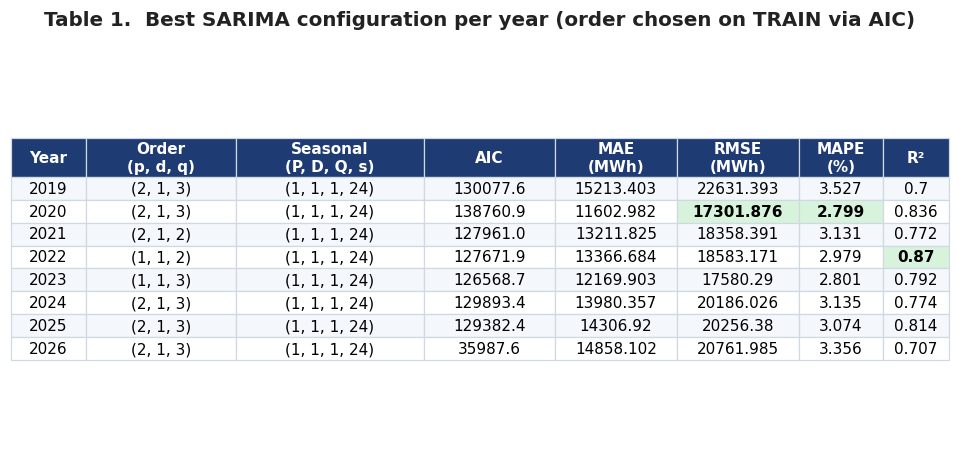

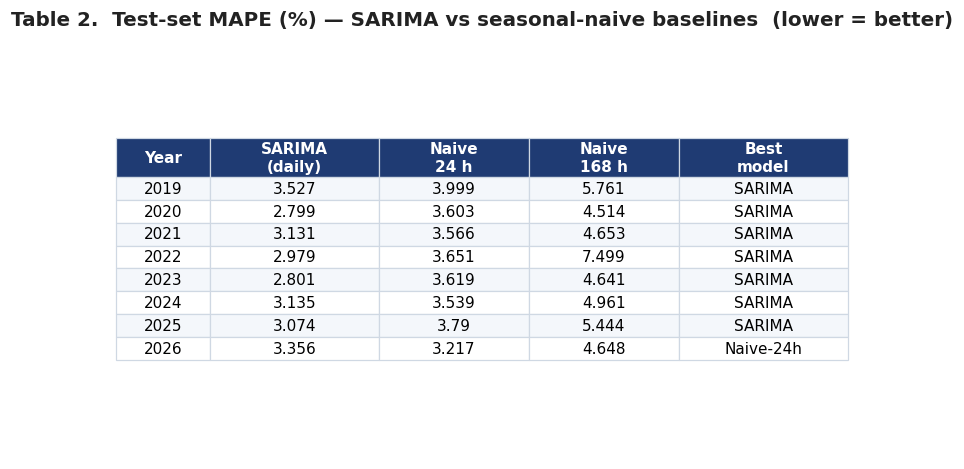

Saved Table 1 and Table 2 to /kaggle/working/sarima_outputs/figures


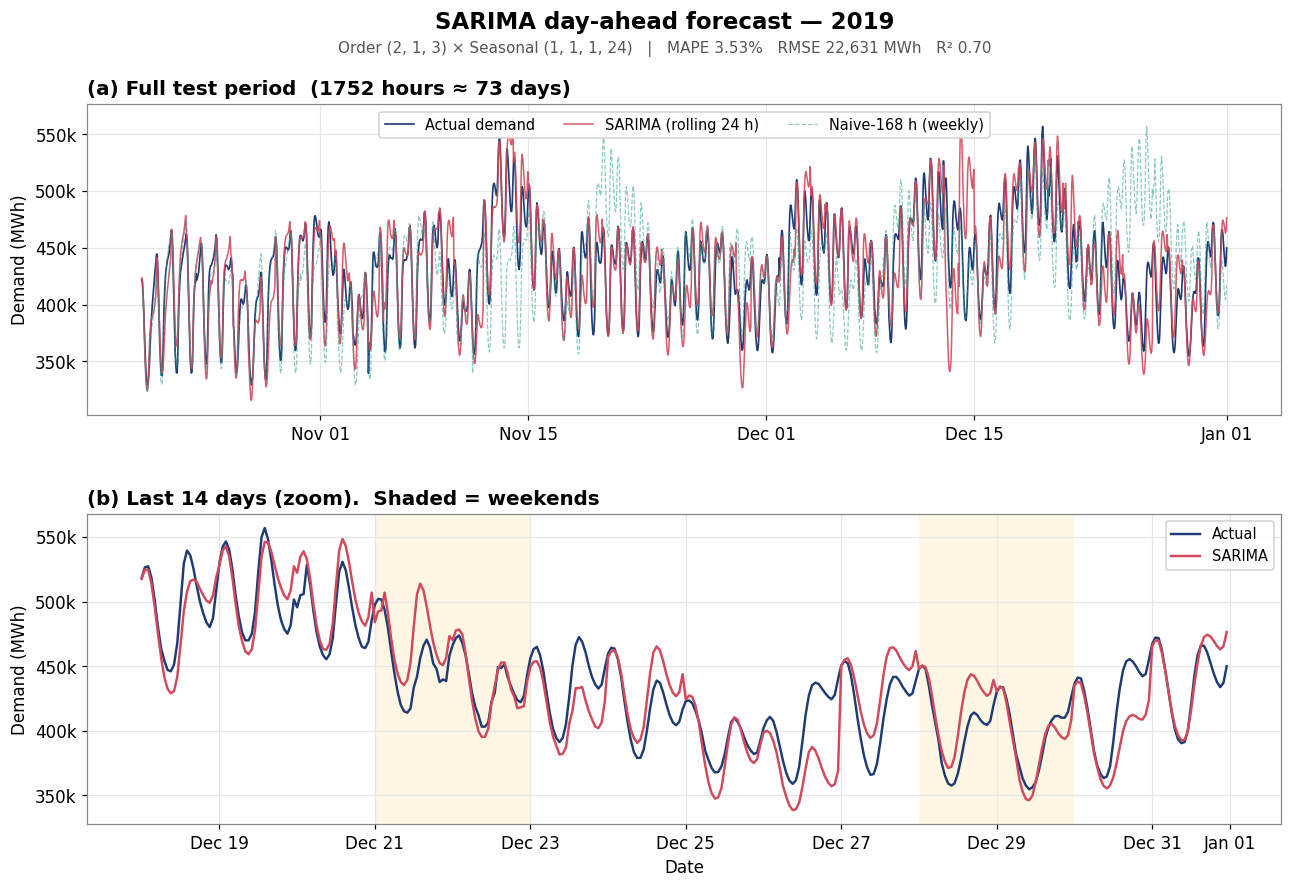

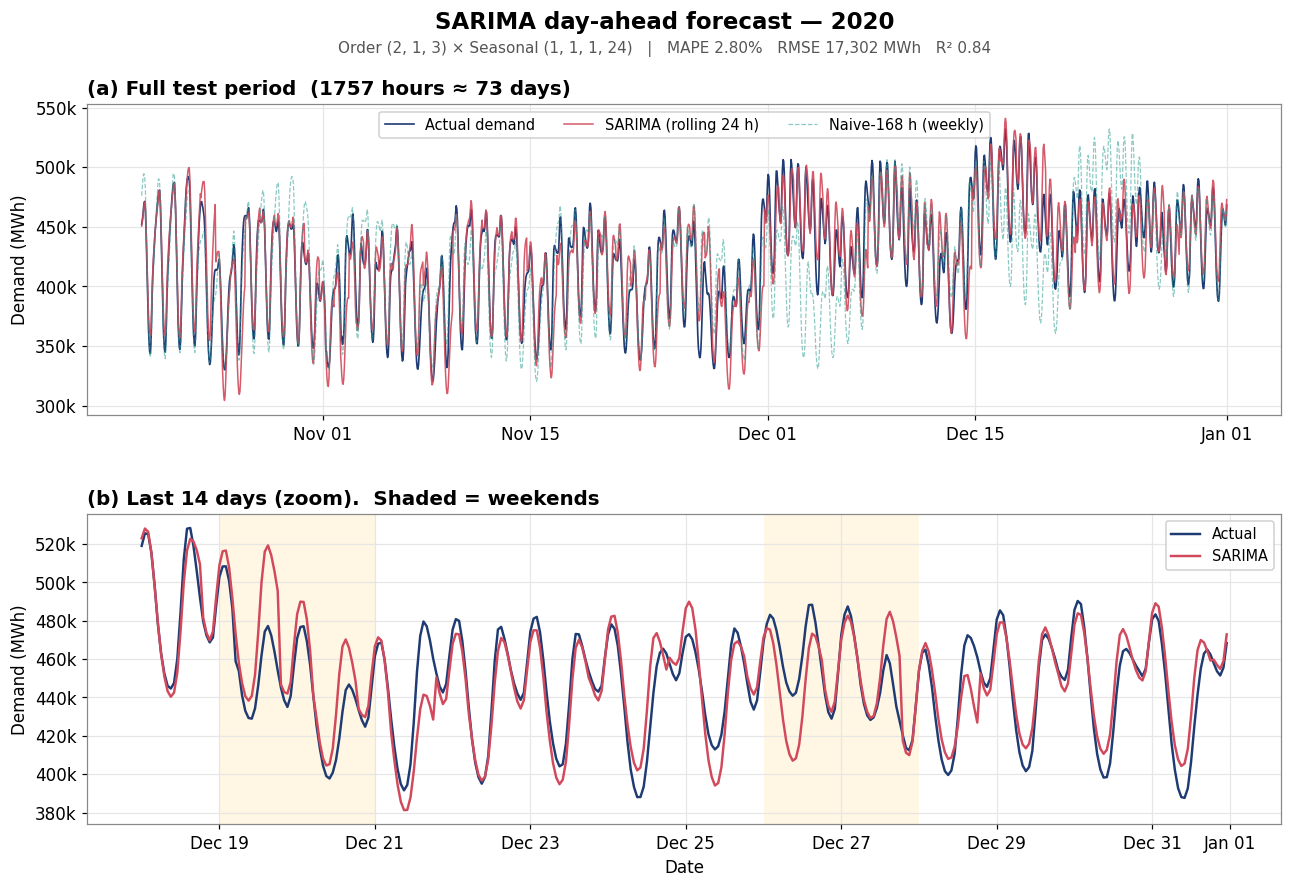

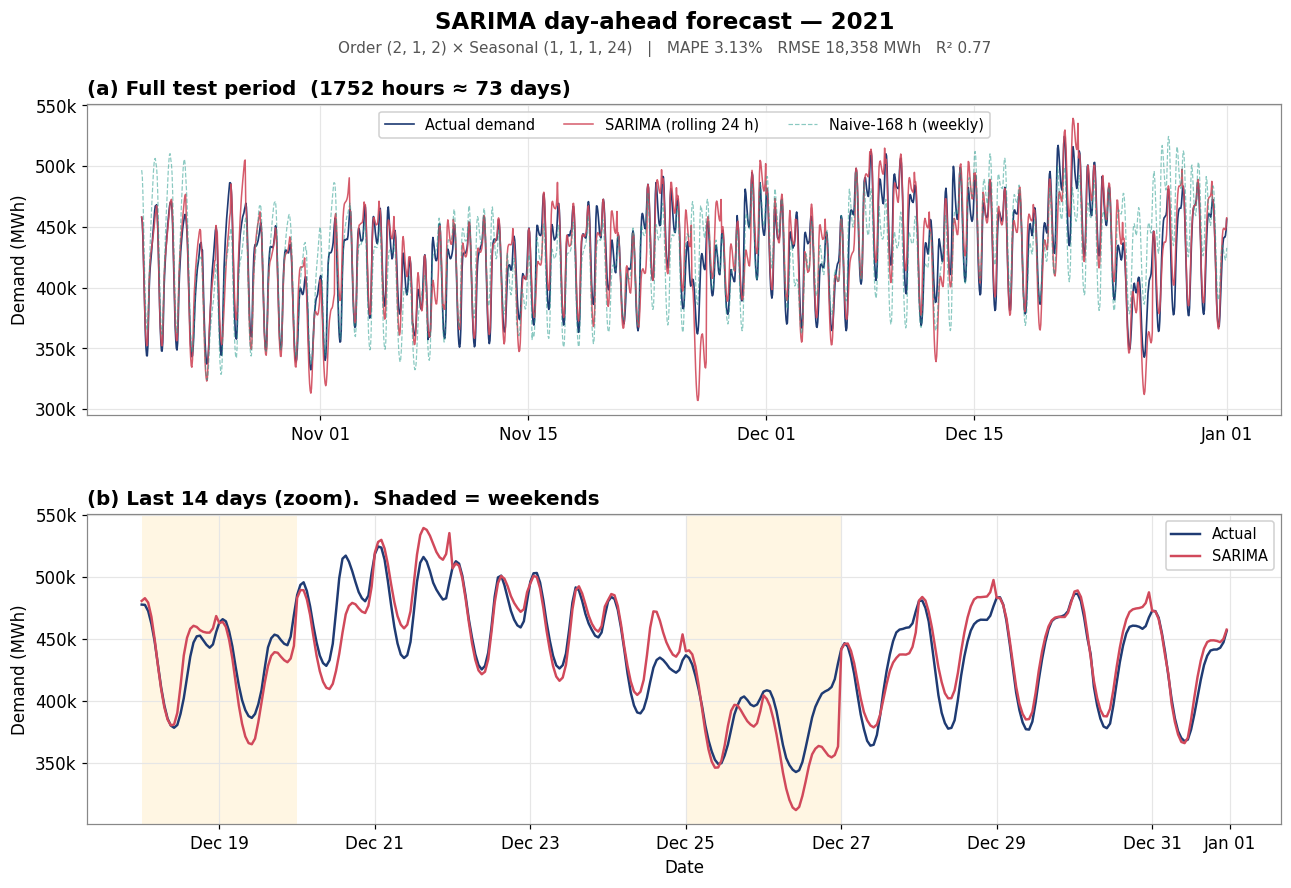

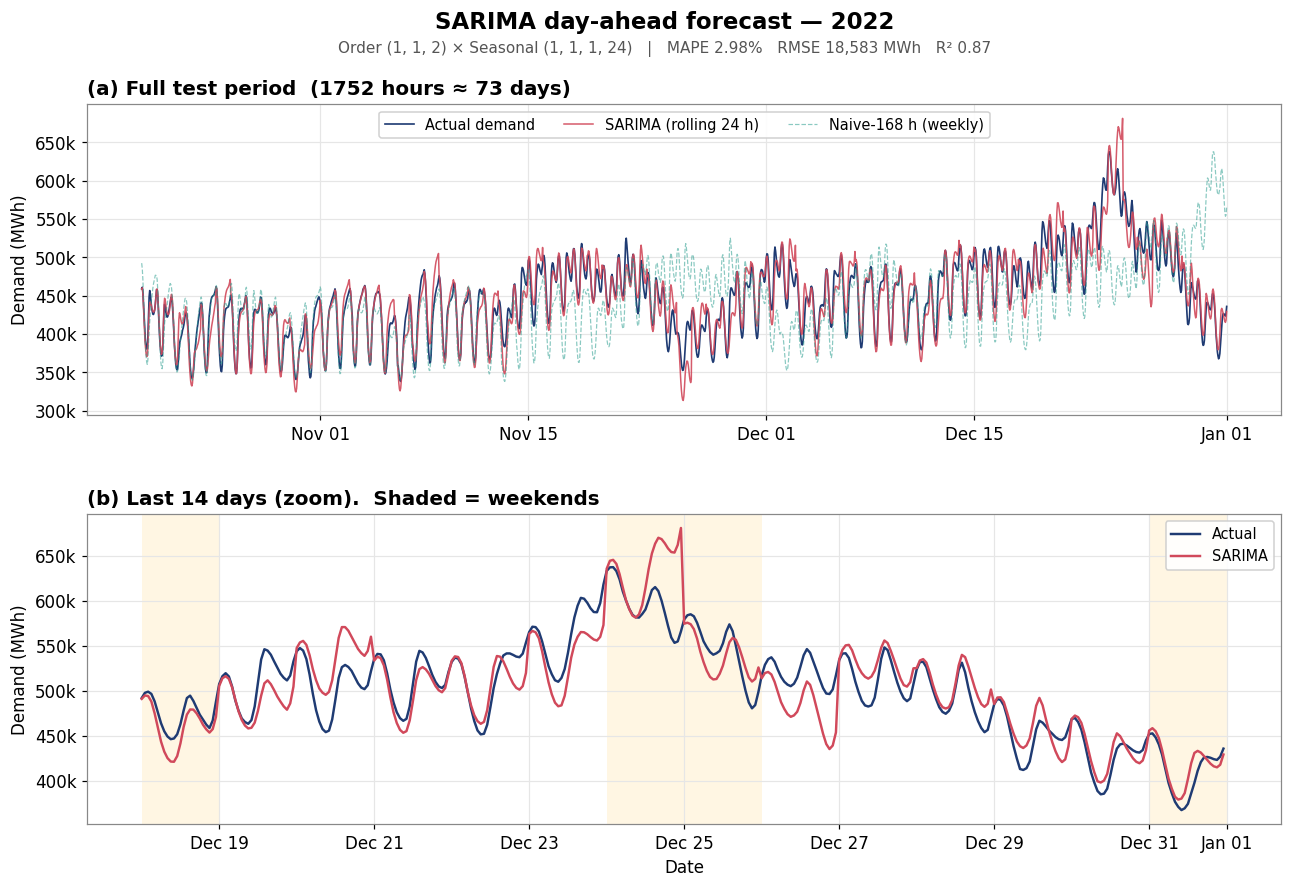

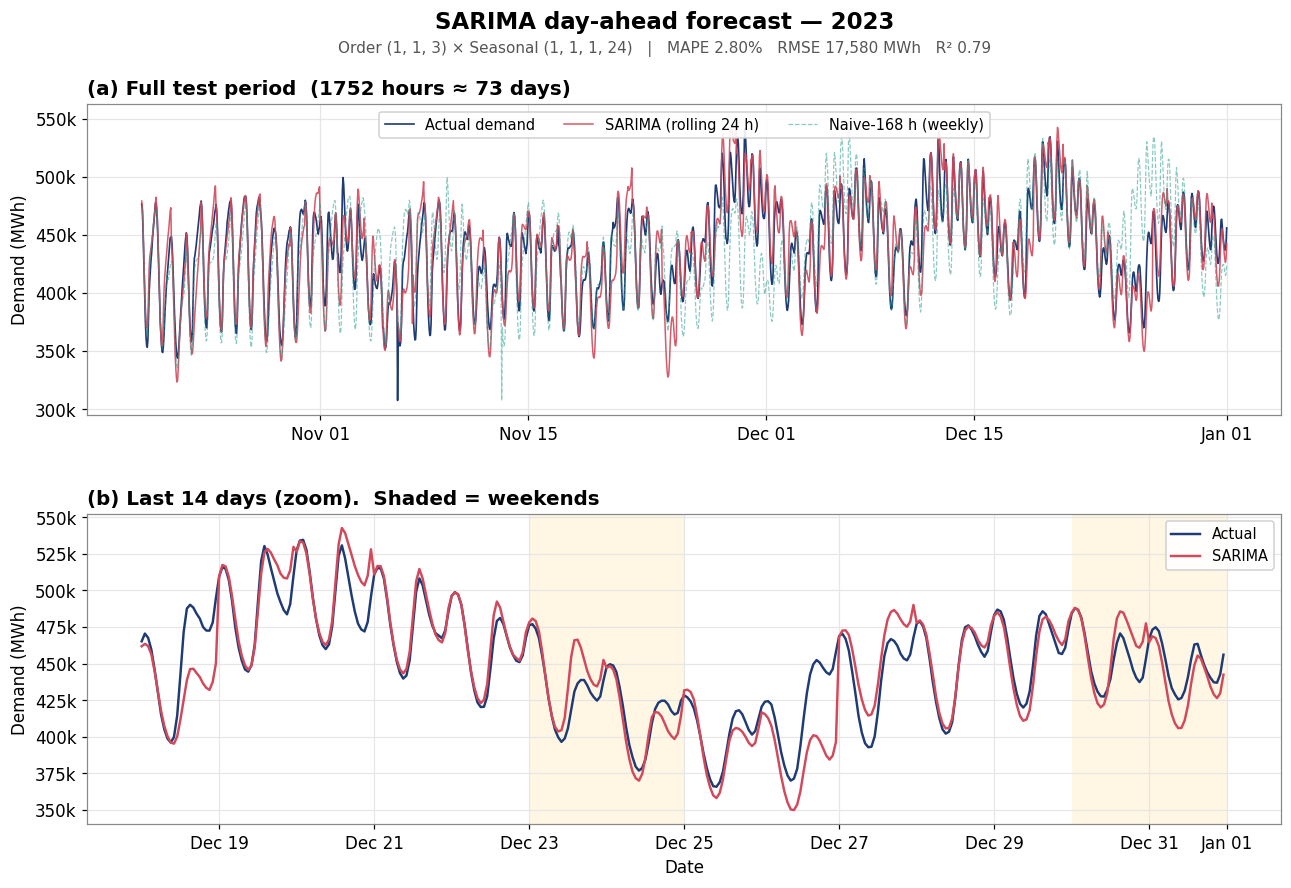

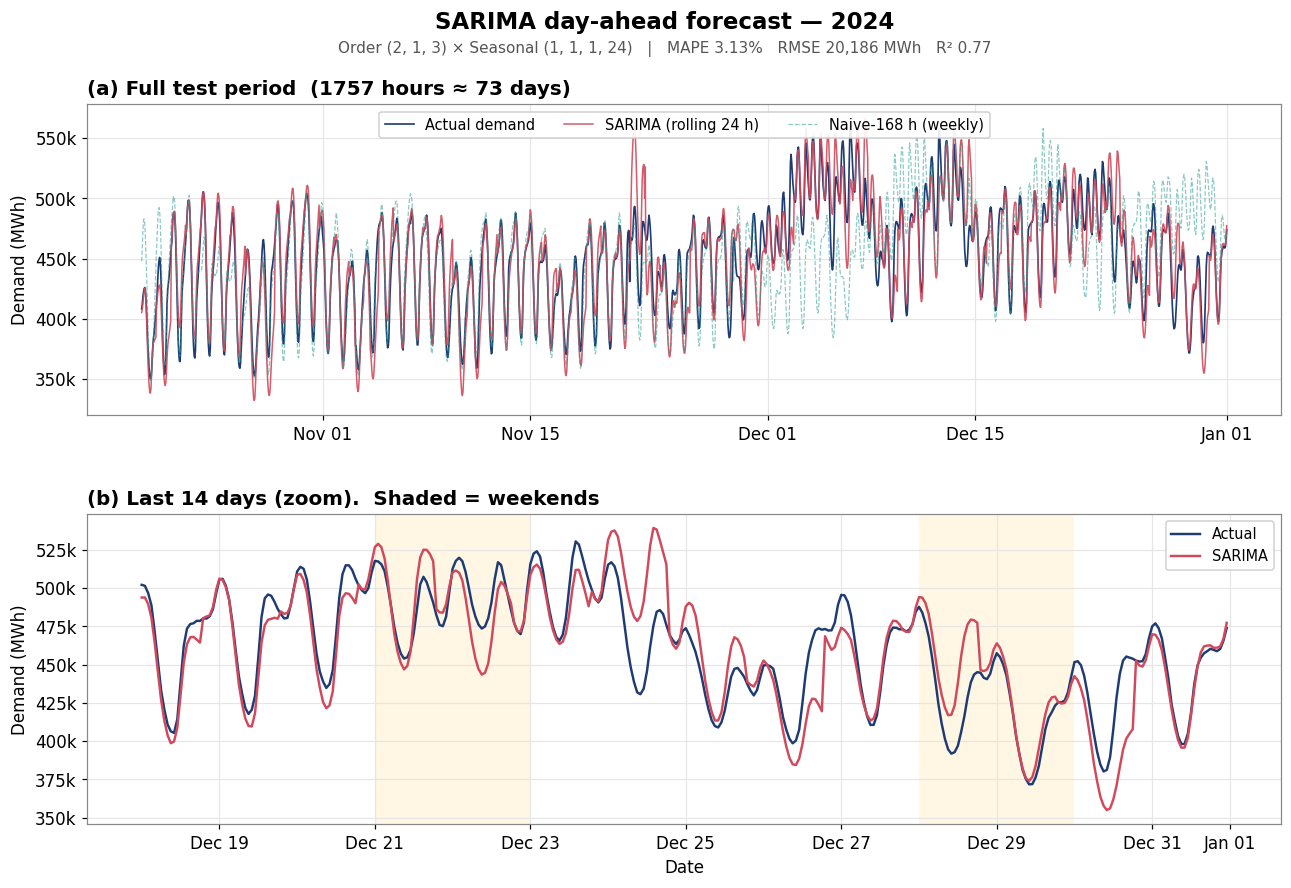

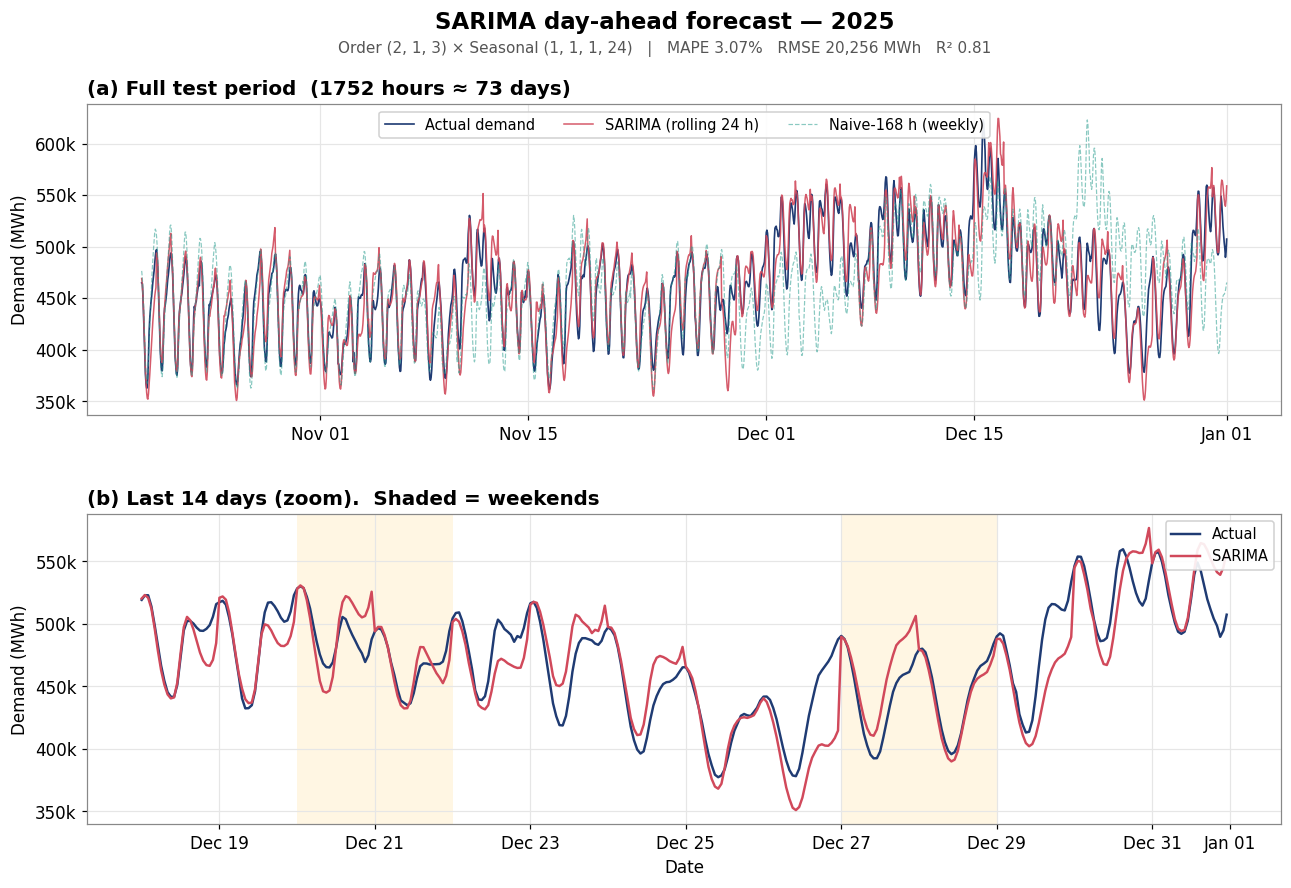

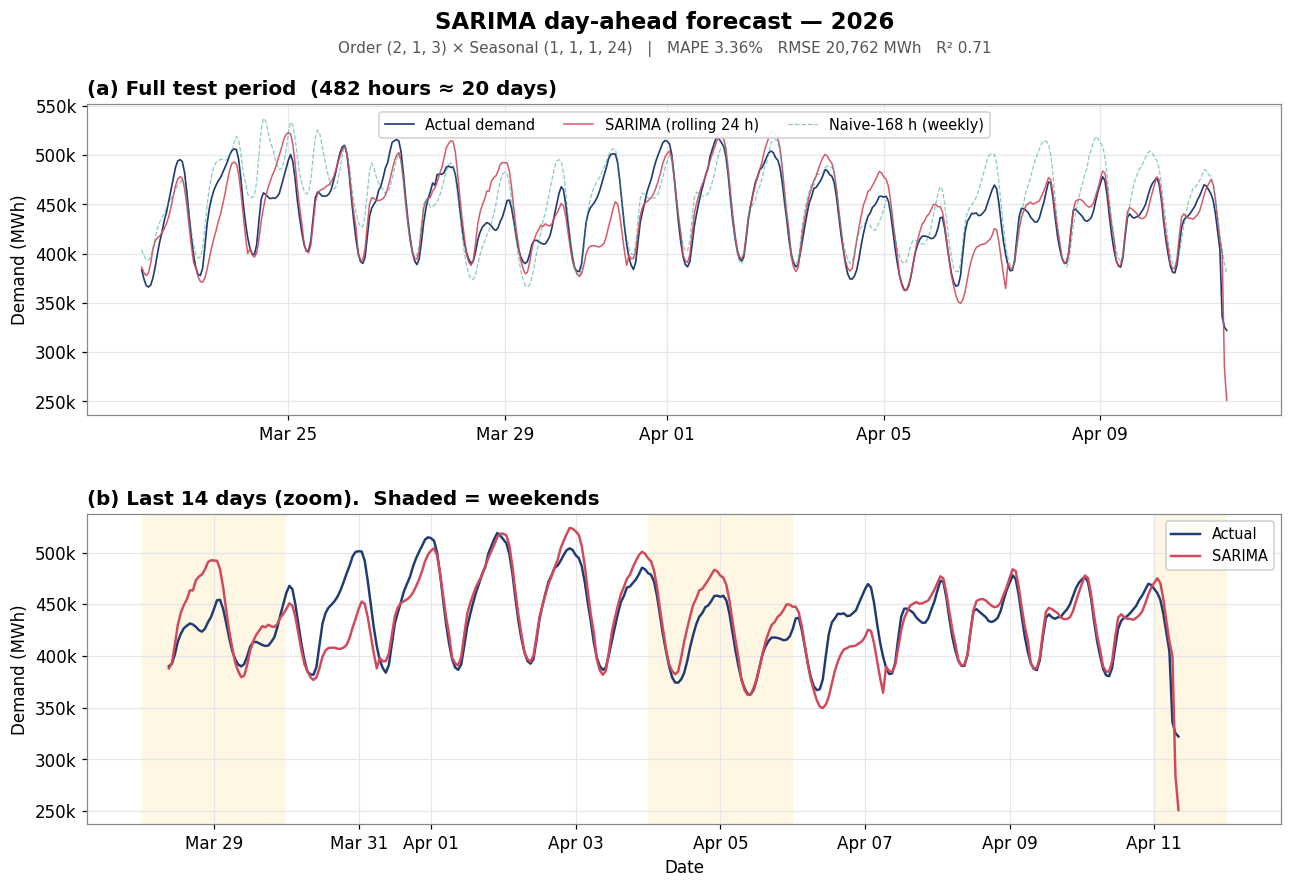

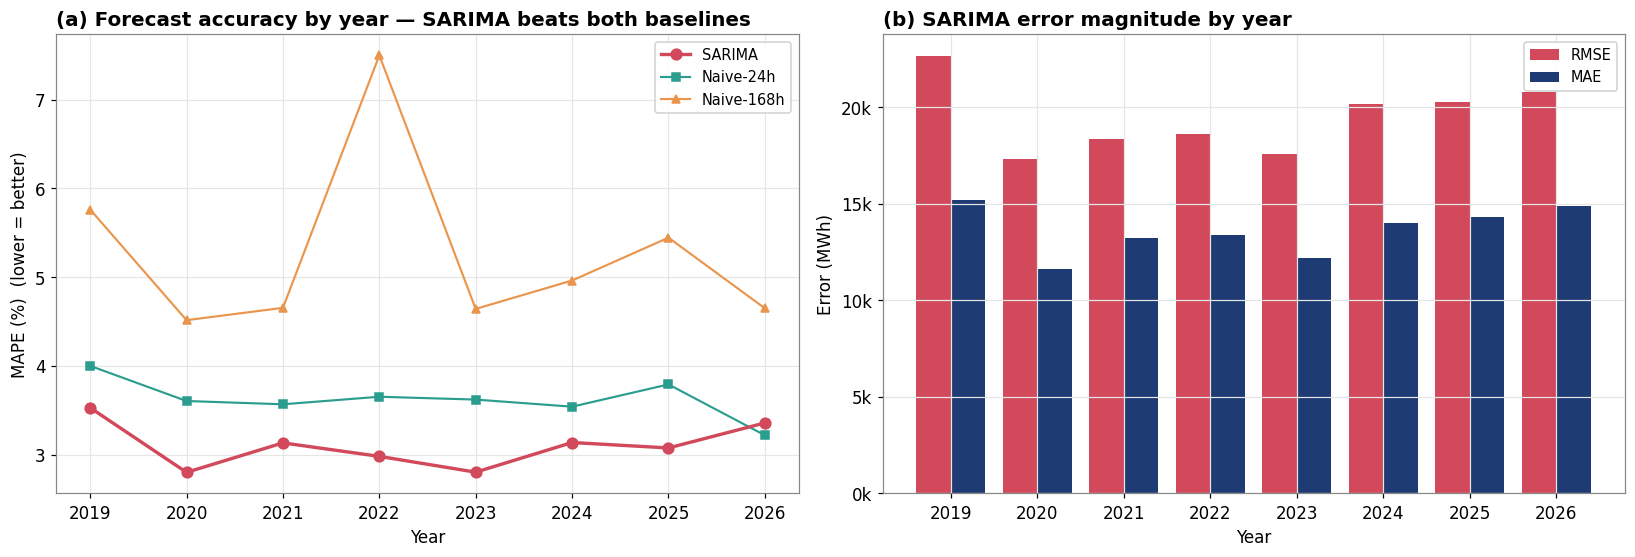


All figures -> /kaggle/working/sarima_outputs/figures
Re-run anytime: Stage 1 is skipped while the cache exists, so editing a
plot/table and re-running is fast. No SARIMA model objects are saved.


In [5]:

# =============================================================================
# MAIN
# =============================================================================
if FORCE_RECOMPUTE or not cache_exists():
    stage1_compute_and_cache()
else:
    print(f"Cache found at {CACHE_DIR} -> skipping Stage 1 (set FORCE_RECOMPUTE=True to redo).")

metrics, best, fcs = load_cache()

print("\n================  BEST SARIMA PER YEAR  ================")
print(best.to_string(index=False))

tableA, tableB = build_tables(metrics, best)
for y in sorted(fcs):
    plot_year(y, fcs[y], best)
plot_error_overview(metrics, best)

print(f"\nAll figures -> {FIG_DIR}")
print("Re-run anytime: Stage 1 is skipped while the cache exists, so editing a")
print("plot/table and re-running is fast. No SARIMA model objects are saved.")